In [1]:
import yfinance as yf
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from datetime import datetime, timedelta

[*********************100%***********************]  1 of 1 completed

(3902, 5)


<Axes: title={'center': 'TSLA OHLC'}, xlabel='Date'>

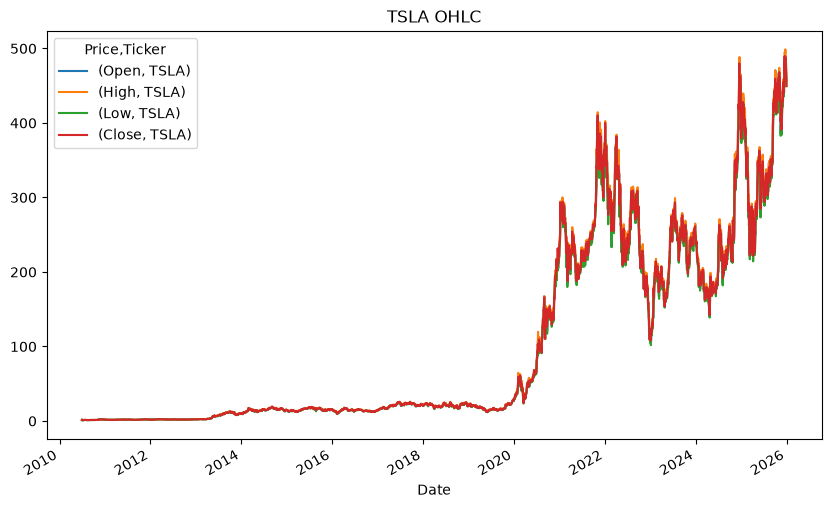

In [2]:
# --- Pull data with yfinance ---

# 1) Single ticker over a fixed date range.
#    auto_adjust=True returns split/dividend-adjusted OHLC.
df = yf.download("TSLA", start="1996-01-01", end="2026-01-01", auto_adjust=True)
print(df.shape)
df.plot(y=["Open", "High", "Low", "Close"], title="TSLA OHLC", figsize=(10, 6))

In [5]:
# 2) Relative period + interval instead of explicit dates.
#    period: 1d,5d,1mo,3mo,6mo,1y,2y,5y,10y,ytd,max
#    interval: 1m,2m,5m,15m,30m,60m,1h,1d,1wk,1mo (intraday limited to ~last 60 days)
spy = yf.download("SPY", period="6mo", interval="1d", auto_adjust=True)
spy.tail()


[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,SPY,SPY,SPY,SPY,SPY
Date,,,,,
2026-06-08,739.219971,745.340027,738.190002,743.359985,49319100
2026-06-09,737.049988,746.900024,722.590027,743.630005,87683500
2026-06-10,725.429993,738.380005,725.330017,733.390015,60341300
2026-06-11,737.760010,740.000000,724.409973,728.760010,86330500
2026-06-12,741.750000,744.440002,735.030029,740.710022,56939800


[*********************100%***********************]  5 of 5 completed


<Axes: title={'center': 'AAPL, MSFT, GOOG, AMZN, NVDA Close Price'}, xlabel='Date'>

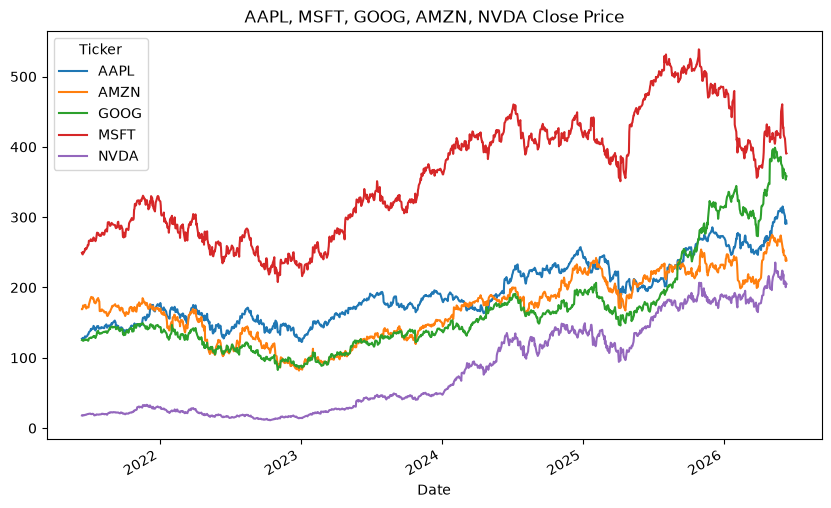

In [ ]:
# 3) Multiple tickers at once -> columns become a MultiIndex (field, ticker).
#    group_by="ticker" flips it to (ticker, field) if you prefer.
data = yf.download(["AAPL", "MSFT", "GOOG", "AMZN", "NVDA"], period="5y", auto_adjust=True)
close = data["Close"]          # DataFrame: one column per ticker
close
close.plot(title="AAPL, MSFT, GOOG, AMZN, NVDA Close Price", figsize=(10, 6))
t

In [21]:
# 4) The Ticker object gives history + metadata (fundamentals, dividends, etc.)
aapl = yf.Ticker("AAPL")
hist = aapl.history(period="1mo")        # OHLCV DataFrame
print(aapl.info.get("longName"), "| sector:", aapl.info.get("sector"))
print("dividends:\n", aapl.dividends.tail())
hist.head()


Apple Inc. | sector: Technology
dividends:
 Date
2025-05-12 09:30:00-04:00    0.26
2025-08-11 09:30:00-04:00    0.26
2025-11-10 09:30:00-05:00    0.26
2026-02-09 09:30:00-05:00    0.26
2026-05-11 09:30:00-04:00    0.27
Name: Dividends, dtype: float64


,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2026-05-13 00:00:00-04:00,293.500000,300.920013,293.500000,298.869995,52684300,0.0,0.0
2026-05-14 00:00:00-04:00,299.820007,300.450012,295.380005,298.209991,35324900,0.0,0.0
2026-05-15 00:00:00-04:00,297.899994,303.200012,296.519989,300.230011,54862800,0.0,0.0
2026-05-18 00:00:00-04:00,300.239990,300.660004,294.910004,297.839996,34483000,0.0,0.0
2026-05-19 00:00:00-04:00,296.970001,300.510010,296.350006,298.970001,42243600,0.0,0.0
